# Key aliases

A style can rename the lookup prefix before it reaches the settings: `{"sma": "overlay", "ema": "overlay"}` makes every moving average resolve to `overlay.color` instead of `sma.color` / `ema.color`. One key means one cycle, so a list value there is a palette shared *across* indicators — the mplfinance `mavcolors` model. Design note: `notes/styler-aliases.md`.

The setup below makes the effect impossible to miss: a monochrome base stylesheet, so anything the alias claims is the only color on the chart. `SMA` and `EMA` are aliased; `LINREG` is not, and falls through to the sheet's own cycle.

In [1]:
from mintalib.indicators import LINREG

from mplchart.chart import Chart
from mplchart.indicators import EMA, SMA
from mplchart.primitives import Candlesticks
from mplchart.samples import sample_prices
from mplchart.styles import Styler

prices = sample_prices()

## A styler built by hand

`grayscale` is a stock matplotlib stylesheet — its prop cycle is shades of grey, and unstyled lines draw in it. The three vivid colors exist nowhere but `overlay.color`, so seeing one on the chart proves the alias fired.

In [2]:
PALETTE = ["#e63946", "#1d9bf0", "#f4a261"]

styler = Styler(
    stylesheet="grayscale",
    rcparams={"axes.grid": True, "grid.alpha": 0.3},
    settings={"overlay.color": PALETTE},
    aliases={"sma": "overlay", "ema": "overlay"},
)

## Where each name lands

`resolve_key` is the whole walk — name → prefix → alias → key — and needs no chart. It is the cheapest way to answer "did the alias apply?".

In [3]:
for name in ("EMA(20)", "SMA(200)", "LINREG(20)", "candle.up"):
    print(f"{name:12} -> {styler.resolve_key(name, 'color')}")

EMA(20)      -> overlay.color
SMA(200)     -> overlay.color
LINREG(20)   -> linreg.color
candle.up    -> candle.up.color


## The chart

Four overlays. The three aliased ones take successive palette entries — note that the cursor is shared *across* prefixes: `EMA` picks up where `EMA` left off, and `SMA` continues the same sequence rather than starting its own. `LINREG` has no alias and no setting of its own, so it resolves through the fallback to the stylesheet's cycle and comes out grey.

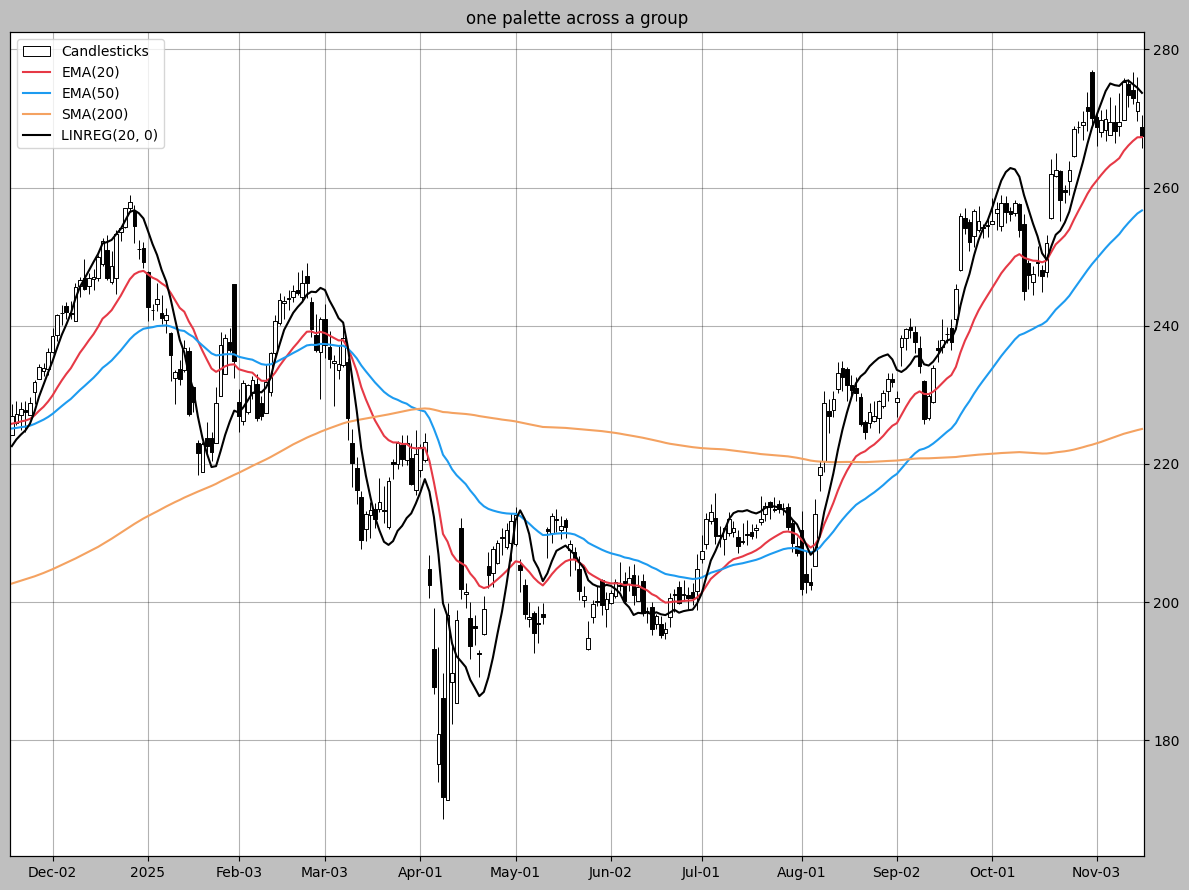

In [4]:
chart = Chart(prices, title="one palette across a group", max_bars=250, style=styler).plot(
    Candlesticks(),
    EMA(20), EMA(50), SMA(200),
    LINREG(20),
)

chart.show()

## Reading it back

Every aliased overlay must be an entry of `overlay.color`, and the unaliased one must not be.

In [5]:
print("palette:", PALETTE)

for line in chart.canvas.main_axes().lines:
    color = line.get_color()
    print(f"{line.get_label():16} {color}  {'palette' if color in PALETTE else 'stylesheet cycle'}")

palette: ['#e63946', '#1d9bf0', '#f4a261']
EMA(20)          #e63946  palette
EMA(50)          #1d9bf0  palette
SMA(200)         #f4a261  palette
LINREG(20, 0)    #000000  stylesheet cycle


## More overlays than colors

The cycle wraps rather than falling through to the prop cycle — a two-color palette is a deliberate way to say "every moving average looks alike" (mplfinance's `tradingview` style does exactly that). Here the fourth and fifth overlays come back around to the start of the palette.

EMA(10)    #e63946
EMA(20)    #1d9bf0
EMA(50)    #f4a261
EMA(100)   #e63946
EMA(200)   #1d9bf0


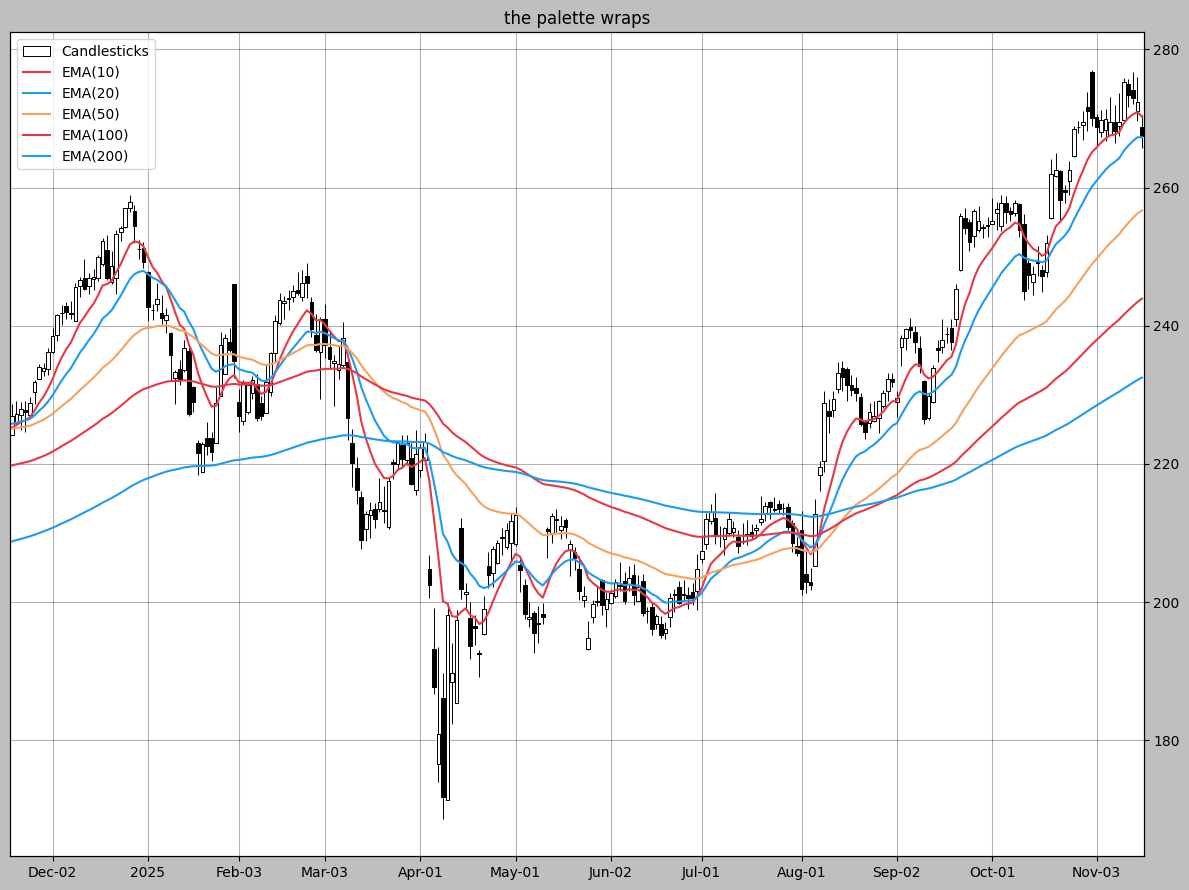

In [6]:
wrapped = Chart(prices, title="the palette wraps", max_bars=250, style=styler).plot(
    Candlesticks(), EMA(10), EMA(20), EMA(50), EMA(100), EMA(200),
)

for line in wrapped.canvas.main_axes().lines:
    print(f"{line.get_label():10} {line.get_color()}")

wrapped.show()

## The alias is a rename, not a fallback

The pre-alias prefix is never tried. So a style that aliases `ema` and also sets `ema.color` silently shadows the latter — and if the alias target has no setting at all, the lookup finds nothing rather than falling back to the original key. That is why aliases ship *with* the style, a few lines from the settings they shadow.

In [7]:
shadowed = Styler(
    settings={"ema.color": "magenta", "overlay.color": "cyan"},
    aliases={"ema": "overlay"},
)
print("shadowed:", shadowed.resolve_color("EMA(20)"))  # cyan — magenta is unreachable

renamed_away = Styler(settings={"ema.color": "magenta"}, aliases={"ema": "overlay"})
print("no target:", renamed_away.resolve_color("EMA(20)"))  # None — no fallthrough

shadowed: #00ffff
no target: None
